# 3HDM with S₃ flavor symmetry: forcing the vacuum, not tuning it

A generic three-Higgs-doublet potential has dozens of independent quartic
couplings — far too many to be predictive. One standard way to cut that
down is to impose a **discrete flavor symmetry** on the scalar sector: pick
a finite group, assign the doublets to its representations, and keep only
the quartic invariants that group theory allows.

This notebook builds the simplest non-abelian example: $S_3$, the
permutation group on 3 objects, with $(H_1, H_2)$ forming its 2-dimensional
irrep and a third doublet $H_S$ sitting in the trivial singlet. It follows
`examples/thdm_s3.py` step by step, showing two things no earlier feynlag
tutorial needed:

1. **Finite discrete-symmetry invariance.** Every gauge check in prior
   tutorials linearizes the transformation at $\alpha=0$ (a continuous Lie
   group). $S_3$ has no such infinitesimal neighborhood of the identity —
   `feynlag` instead applies the group's *exact, finite* substitution and
   checks the Lagrangian term-by-term for literal equality.
2. **A vacuum that isn't free to choose.** With three VEVs ($v_1, v_2,
   v_S$) but an $S_3$-covariant potential that only has *two* independent
   mass parameters ($\mu_0^2,\mu_1^2$) to absorb tadpole conditions, the
   third condition becomes a real constraint. Solving it doesn't tune a
   free ratio — it **forces** $v_1/v_2$ to a fixed value.

Along the way we also see the $S_3$ Clebsch–Gordan decomposition
$2\otimes2 = 1\oplus1'\oplus2$ that the potential is built from, the
resulting CP-even, pseudoscalar and charged mass matrices, and — following
the literature model this potential is drawn from — a geometric rotation
ansatz that diagonalizes them into seven physical scalar masses.

**Assumed background:** the Higgs mechanism / spontaneous gauge symmetry
breaking, Goldstone's theorem, and enough Lie-group representation theory
to know what a tensor-product (Clebsch–Gordan) decomposition is — the kind
of material a first QFT course plus a group-theory-for-physicists chapter
covers. If tensor products/irreps are new, `SUN_Groups_Tutorial.ipynb`
builds that machinery up from scratch first (for continuous groups; $S_3$
here is discrete, but the tensor-product idea is the same). The
library-specific machinery this notebook exercises (`S3`, `Model`,
`Rotation`, ...) is documented in `docs/manual/declaration.md` and
`docs/manual/ssb.md`.

**Notation used throughout this notebook:**

| Symbol | Meaning |
|---|---|
| $H_1,H_2,H_S$ | the three $SU(2)_L\times U(1)_Y$ Higgs doublets ($H_1,H_2$ in the $S_3$ **2**, $H_S$ in the **1**) |
| $v_1,v_2,v_S$ | their vacuum expectation values |
| $\lambda_1,\ldots,\lambda_8$ | the eight $S_3$-invariant quartic couplings (§2 table) |
| $\mu_0^2,\mu_1^2$ | the singlet/doublet-sector mass² parameters |
| $M_S^2,\,M_A^2,\,M_C^2$ | the CP-even, pseudoscalar (CP-odd) and charged $3\times3$ mass-squared matrices |
| $R(\varphi,\theta)$ | the geometric (coupling-independent) rotation fixed by the vacuum direction alone |
| $\alpha$ | the one genuinely dynamical mixing angle, needed only for the CP-even sector |
| $h_0,H_1,H_2$ | the three physical CP-even scalars |
| $A_1,A_2$ | the two physical pseudoscalars (the third pseudoscalar direction is the $Z$'s Goldstone) |
| $H_1^\pm,H_2^\pm$ | the two physical charged scalars (the third charged direction is the $W^\pm$'s Goldstone) |

Keep this table in view — the notebook builds every one of these from
scratch, in this order.

## 1. Symmetries, parameters, fields

$S_3$ has three irreducible representations:

- $\mathbf{1}$ — trivial: every group element acts as $+1$.
- $\mathbf{1'}$ — the sign representation: the 3-cycle acts as $+1$, the
  transposition as $-1$.
- $\mathbf{2}$ — a genuine 2-dimensional (real, orthogonal) doublet:
  `feynlag`'s `S3` represents the 3-cycle generator as a $2\pi/3$ rotation
  matrix and the transposition generator as a reflection
  $\mathrm{diag}(1,-1)$.

`s3.assign(irrep, *fields)` below registers which fields sit in which
irrep and builds, from those generator matrices, an explicit finite
substitution map (one linear combination of components per group
generator) — this is what `check_discrete_invariance` later applies
*exactly*, in contrast to the $O(\alpha)$ linearized check every gauge
symmetry in this library uses.

We also declare the usual electroweak gauge sector ($SU(2)_L\times U(1)_Y$)
alongside $S_3$ — the potential must satisfy *both* symmetries at once.

In [ ]:
import sympy as sp
from IPython.display import display
sp.init_printing()

from feynlag import (
    ExternalParameter, InternalParameter, Lagrangian, Model, S3, SU2,
    Scalar, U1, check_discrete_invariance, dag,
)

gw = ExternalParameter("g_w", 0.6535, positive=True)
g1 = ExternalParameter("g_1", 0.3580, positive=True)
SU2L, U1Y = SU2("SU2L", coupling=gw), U1("U1Y", coupling=g1)
s3 = S3()

v1 = ExternalParameter("v_1", 200.0, positive=True, unit_dim=1)
v2 = ExternalParameter("v_2", 115.0, positive=True, unit_dim=1)
vS = ExternalParameter("v_S", 80.0, positive=True, unit_dim=1)
lams = {k: ExternalParameter(f"lambda_{k}", 0.05 * k) for k in range(1, 9)}
mu0sq = InternalParameter("mu0sq", unit_dim=2)
mu1sq = InternalParameter("mu1sq", unit_dim=2)

$v_1,v_2,v_S=200,115,80$ GeV aren't arbitrary: they're chosen so that
$\sqrt{v_1^2+v_2^2+v_S^2}\approx246$ GeV, the single familiar SM Higgs VEV
— [GomezBock21]'s Eq. (8) constraint. Three doublets, one combined scale.

Before wiring up real fields, let's see the $2\otimes2$
Clebsch–Gordan decomposition on abstract symbols — `S3.doublet_product`
returns the three channels the tensor product of two doublets splits
into.

In [ ]:
a1, a2, b1, b2 = sp.symbols("a1 a2 b1 b2")
cg = s3.doublet_product((a1, a2), (b1, b2))
cg

{'1': a1*b1 + a2*b2, '1p': a1*b2 - a2*b1, '2': (a1*b1 - a2*b2, -a1*b2 - a2*b1)}

So $2\otimes2 = 1\oplus1'\oplus2$: a singlet ($a_1b_1+a_2b_2$), a
pseudo-singlet ($a_1b_2-a_2b_1$), and — since a doublet's tensor square
must contain another doublet — a second copy of the **2** itself. We'll
reuse these exact three combinations below, applied not to raw field
components but to the gauge-invariant bilinears $H_i^\dagger H_j$.

## 2. Building the $S_3$-covariant potential from Clebsch–Gordan invariants

$H_1, H_2, H_S$ are three ordinary $SU(2)_L\times U(1)_Y$ Higgs doublets.
`s3.assign("2", H1, H2)` puts $(H_1,H_2)$ in the doublet irrep;
`s3.assign("1", HS)` puts $H_S$ in the trivial singlet.

In [ ]:
def doublet(name):
    return Scalar(name, reps={SU2L: 2, U1Y: sp.Rational(1, 2)},
                  component_names=[f"{name}p", f"{name}0"])

H1, H2, HS = doublet("H_1"), doublet("H_2"), doublet("H_S")
s3.assign("2", H1, H2)
s3.assign("1", HS)

H1.expand_vev({H1.components[1]: v1})
H2.expand_vev({H2.components[1]: v2})
HS.expand_vev({HS.components[1]: vS})

Scalar('H_S')

`bra(a, b)` builds the $SU(2)_L\times U(1)_Y$-invariant bilinear
$a^\dagger b$. The doublet-index CG formulas from above apply directly to
these bilinears, with $(a_1,a_2)=(H_1^\dagger,H_2^\dagger)$ on the bra side
and $(b_1,b_2)=(H_1,H_2)$ on the ket side: $a_1b_1\to H_1^\dagger H_1$,
$a_1b_2\to H_1^\dagger H_2$, and so on.

In [ ]:
def bra(a, b):
    return (dag(a) * b.mat)[0]

x11, x22 = bra(H1, H1), bra(H2, H2)
x12, x21 = bra(H1, H2), bra(H2, H1)
s1, s2 = bra(HS, H1), bra(HS, H2)
sss = bra(HS, HS)

inv1 = x11 + x22          # the '1' channel:  a1*b1 + a2*b2
inv1p = x12 - x21         # the '1\'' channel: a1*b2 - a2*b1
d2 = (x11 - x22, -(x12 + x21))   # the '2' channel

display(inv1)
display(inv1p)
display(d2)

$H_S$ enters the potential through its own doublet of bilinears,
$(s_1,s_2)=(H_S^\dagger H_1,\,H_S^\dagger H_2)$, which transforms exactly
like $(H_1,H_2)$ under $S_3$. Contracting this doublet with itself, or
with the $(H_1,H_2)$ doublet channel `d2`, gives two more singlet
invariants — both need an explicit $+\text{h.c.}$ since neither
combination is manifestly real on its own.

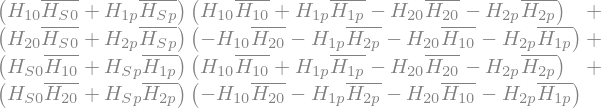

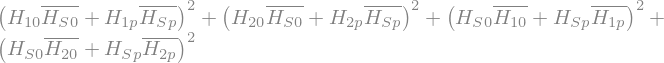

In [ ]:
lam4_term = s1 * d2[0] + s2 * d2[1]
lam4_term += sp.conjugate(lam4_term)     # (HS†H)_2 ⊗ (H†H)_2 → 1, + h.c.

lam7_term = s1**2 + s2**2
lam7_term += sp.conjugate(lam7_term)     # (HS†H)_2 ⊗ (HS†H)_2 → 1, + h.c.

display(lam4_term)
display(lam7_term)

All 8 quartic couplings are now S₃-invariant combinations built from
`inv1`, `inv1p`, `d2`, `lam4_term`, `lam7_term`, `sss`:

| Coupling | CG channel | Term | Role |
|---|---|---|---|
| $\lambda_1$ | $1\otimes1$ | $(H_1^\dagger H_1+H_2^\dagger H_2)^2$ | ordinary doublet-sector quartic |
| $\lambda_2$ | $1'\otimes1'$ | $(H_1^\dagger H_2-H_2^\dagger H_1)^2$ | pseudo-singlet quartic |
| $\lambda_3$ | $2\otimes2\to1$ | $d_2\cdot d_2$ | doublet-channel self-contraction |
| $\lambda_4$ | $(H_S^\dagger H)_2\otimes(H^\dagger H)_2\to1$, + h.c. | $s\cdot d_2$ + h.c. | singlet–doublet mixed quartic |
| $\lambda_5$ | $1\otimes1$ | $(H_S^\dagger H_S)(H_1^\dagger H_1+H_2^\dagger H_2)$ | portal-like singlet×doublet-norm coupling |
| $\lambda_6$ | $2\otimes\bar2\to1$ | $s_1(H_1^\dagger H_S)+s_2(H_2^\dagger H_S)$ | $|s_1|^2+|s_2|^2$-type cross term |
| $\lambda_7$ | $(H_S^\dagger H)_2\otimes(H_S^\dagger H)_2\to1$, + h.c. | $s_1^2+s_2^2$ + h.c. | CP-sensitive; needs + h.c. to be Hermitian |
| $\lambda_8$ | $1\otimes1$ | $(H_S^\dagger H_S)^2$ | pure singlet quartic |

plus a mass term for each $S_3$ singlet sector, $\mu_1^2(H_1^\dagger
H_1+H_2^\dagger H_2)$ and $\mu_0^2 H_S^\dagger H_S$.

In [ ]:
l = {k: p.s for k, p in lams.items()}
V = (mu1sq.s * inv1 + mu0sq.s * sss
     + l[1] * inv1**2 + l[2] * inv1p**2
     + l[3] * (d2[0]**2 + d2[1]**2)
     + l[4] * lam4_term
     + l[5] * sss * inv1
     + l[6] * (s1 * bra(H1, HS) + s2 * bra(H2, HS))
     + l[7] * lam7_term
     + l[8] * sss**2)

L = Lagrangian().add(-V, sector="potential")

## 3. Assemble the model and check invariance

Everything above was built from gauge-invariant bilinears and $S_3$
Clebsch–Gordan combinations by hand — but nothing has actually *verified*
gauge or $S_3$ invariance yet. `Model.check_invariance()` checks every
term against both `gauge_groups` and `discrete_groups` at once.

In [ ]:
model = Model("3HDM-S3", gauge_groups=[SU2L, U1Y], discrete_groups=[s3],
              fields=[H1, H2, HS],
              parameters=[gw, g1, v1, v2, vS, mu0sq, mu1sq,
                          *lams.values()],
              lagrangian=L)

report = model.check_invariance()
print("invariant:", report.ok)
if not report.ok:
    print(report.failures)

invariant: True


In plain terms: every coupling written into $V$ is simultaneously
*allowed* — there's no hidden tension between the gauge and $S_3$
symmetries that would force some $\lambda_k$ to vanish.

What if a term *weren't* $S_3$-invariant? Take, for instance,
$(H_S^\dagger H_1)(H_1^\dagger H_1) + \text{h.c.}$ — it singles out $H_1$
without pairing it with the matching $H_2$ combination the doublet
structure requires. `check_discrete_invariance` catches this directly,
without needing a full `Model`.

In [ ]:
bad = (dag(HS) * H1.mat)[0] * (dag(H1) * H1.mat)[0]
bad = bad + sp.conjugate(bad)

ok, _ = check_discrete_invariance(bad, s3)
print("forbidden term is S3-invariant?", ok)

forbidden term is S3-invariant? False


## 4. Tadpoles and the forced $\sqrt3$ vacuum alignment

There are three VEVs ($v_1,v_2,v_S$) but the $S_3$-covariant potential
only has **two** independent mass parameters ($\mu_0^2,\mu_1^2$) free to
absorb tadpole conditions. Solving the $v_2$ and $v_S$ conditions for
$\mu_0^2,\mu_1^2$ and substituting into the $v_1$ condition therefore
leaves a genuine constraint on $v_1,v_2$ alone — not an identity.

residual v1-tadpole condition:


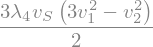

In [ ]:
tadpoles = model.tadpoles()
t1, t2, tS = tadpoles[v1.s], tadpoles[v2.s], tadpoles[vS.s]

sol = sp.solve([sp.Eq(t2, 0), sp.Eq(tS, 0)], [mu0sq.s, mu1sq.s], dict=True)[0]
residual = sp.factor(sp.expand(t1.subs(sol)))
print("residual v1-tadpole condition:")
display(residual)

The residual factors as $\propto v_S(3v_1^2 - v_2^2)$: since
$v_S\neq0$, the only way to satisfy all three tadpole conditions
simultaneously is $v_1^2 = v_2^2/3$ — a fixed ratio, not a free parameter.
(`docs/manual/ssb.md` frames this as a structural consequence of the CG
structure, not a coincidence of the numeric benchmark point; the
`declaration.md` chapter notes that `feynlag`'s real-orthogonal $S_3$
basis swaps which doublet component the literature's $v_1=\sqrt3\,v_2$
convention refers to — the ratio *squared* is the basis-independent
statement.)

This exact relation was independently derived in the literature model this
potential is drawn from: **[GomezBock21]** M. Gómez-Bock, M. Mondragón, A.
Pérez-Martínez, *"Scalar and gauge sectors in the 3-Higgs Doublet Model
under the S₃-symmetry"*, Eur. Phys. J. C **81**, 942 (2021),
[arXiv:2102.02800](https://arxiv.org/abs/2102.02800),
[doi:10.1140/epjc/s10052-021-09731-3](https://doi.org/10.1140/epjc/s10052-021-09731-3)
— their Eq. (13) tadpole solution is exactly $v_1^2=3v_2^2$ (their
$v_1,v_2$; the basis swap above is what turns this into our
$v_1^2=v_2^2/3$).

In [ ]:
v1_solutions = sp.solve(sp.Eq(residual, 0), v1.s)
print("v1 solutions:", v1_solutions)
for s_v1 in v1_solutions:
    ratio_sq = sp.simplify((s_v1 / v2.s) ** 2)
    print("  (v1/v2)^2 =", ratio_sq)

v1 solutions: [sqrt(3)*v_2/3]
  (v1/v2)^2 = 1/3


In plain terms: naively, three VEVs minus three tadpole conditions
should still leave one free ratio to fit experimentally — instead the
$S_3$ structure removes it. The model has one fewer free continuous
parameter than the field content alone would suggest.

## 5. CP-even mass matrix on the aligned vacuum

Imposing the alignment and re-solving the two mass parameters
consistently, the $v_1$ tadpole condition is now automatically satisfied
— confirming the alignment is exactly what's needed, not an
approximation.

In [ ]:
align = {v1.s: v2.s / sp.sqrt(3)}

sol2 = sp.solve([sp.Eq(tadpoles[v2.s].subs(align), 0),
                 sp.Eq(tadpoles[vS.s].subs(align), 0)],
                [mu0sq.s, mu1sq.s], dict=True)[0]

print("v1 tadpole after alignment + resolving mu0sq, mu1sq:",
      sp.simplify(tadpoles[v1.s].subs(align).subs(sol2)))

v1 tadpole after alignment + resolving mu0sq, mu1sq: 0


`Model.mass_matrix` takes the real CP-even fluctuations
(`expand_vev`'s auto-generated `{name}0_r` symbols) and returns
$\partial^2V/\partial\phi_i\partial\phi_j$ evaluated on the vacuum, with
any cached tadpole solutions applied automatically.

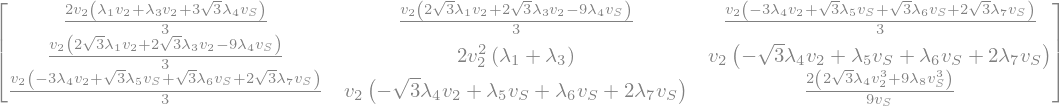

In [ ]:
h = [sp.Symbol(f"{n}0_r", real=True) for n in ("H_1", "H_2", "H_S")]
M = model.mass_matrix(h).subs(sol2).subs(align)
M = M.applyfunc(lambda e: sp.simplify(sp.expand(e)))
M

In [ ]:
print("symmetric:", sp.simplify(M - M.T) == sp.zeros(3, 3))
print("nonzero diagonal:", M[0, 0] != 0 and M[1, 1] != 0 and M[2, 2] != 0)

symmetric: True
nonzero diagonal: True


## 6. The other two scalar sectors: pseudoscalar and charged mass matrices

`thdm_s3.py`'s potential `V` was written from full doublet bilinears
(`bra`, `dag(a)*b.mat`) — it already implicitly contains the charged
($H_1^\pm,H_2^\pm,H_S^\pm$) and imaginary neutral (pseudoscalar) pieces of
every field, even though only the real neutral fluctuations (`_r`
symbols) have been differentiated so far. No new Lagrangian terms are
needed to get the other two sectors, just two more second-derivative
matrices:

- **Pseudoscalar** ($M_A^2$): the same `Model.mass_matrix` used for the
  CP-even sector, applied to `expand_vev`'s imaginary (`_i`) fluctuation
  symbols instead of the real ones.
- **Charged** ($M_C^2$): `Model.mass_matrix(..., charged=True)`, which
  differentiates $\partial^2V/\partial\bar\phi_i\partial\phi_j$ via a
  Dummy-conjugate trick (SymPy can't differentiate w.r.t. `conjugate(φ)`
  directly) — this one takes the **raw** charged component symbols
  (`H1.components[0]`, etc.), not fluctuation symbols, since a charged
  field never gets a VEV and so never had `_r`/`_i` symbols generated for
  it.

M_A symmetric: True
M_C symmetric: True


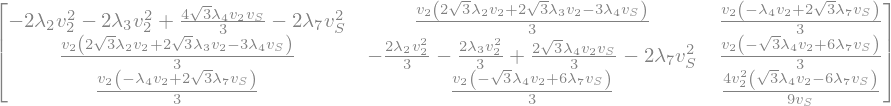

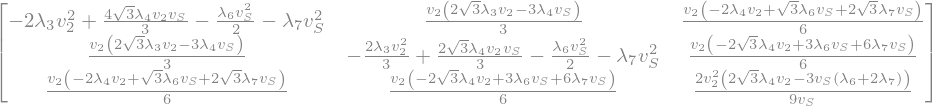

In [ ]:
hi = [sp.Symbol(f"{n}0_i", real=True) for n in ("H_1", "H_2", "H_S")]
M_A = model.mass_matrix(hi).subs(sol2).subs(align)
M_A = M_A.applyfunc(lambda e: sp.simplify(sp.expand(e)))

hc = [H1.components[0], H2.components[0], HS.components[0]]
M_C = model.mass_matrix(hc, charged=True).subs(sol2).subs(align)
M_C = M_C.applyfunc(lambda e: sp.simplify(sp.expand(e)))

print("M_A symmetric:", sp.simplify(M_A - M_A.T) == sp.zeros(3, 3))
print("M_C symmetric:", sp.simplify(M_C - M_C.T) == sp.zeros(3, 3))
display(M_A)
display(M_C)

## 7. The Gómez-Bock–Mondragón–Pérez-Martínez rotation ansatz

**[GomezBock21]** (full citation above) diagonalizes all three sectors with
a rotation built purely from the geometry of the vacuum. Writing
$v_1=v\cos\varphi\sin\theta$, $v_2=v\sin\varphi\sin\theta$, $v_S=v\cos\theta$
(their Eq. 21) — i.e. $\varphi,\theta$ are just the *angles* the VEV vector
makes in $(v_1,v_2,v_S)$-space — their Eq. 25–29 rotation is

$$R(\varphi,\theta)=\begin{pmatrix}\sin\theta\cos\varphi&-\sin\varphi&-\cos\theta\cos\varphi\\\sin\theta\sin\varphi&\cos\varphi&-\cos\theta\sin\varphi\\\cos\theta&0&\sin\theta\end{pmatrix}.$$

Nothing here depends on the potential's couplings — it's fixed the moment
the vacuum direction is known. We build it directly from `feynlag`'s own
$v_1,v_2,v_S$ (no basis translation needed — tested below against the
swapped assignment too, which does *not* diagonalize; this direct one
does).

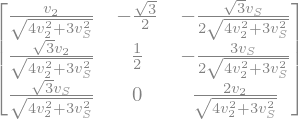

In [ ]:
v12 = sp.sqrt(v1.s**2 + v2.s**2)
vtot = sp.sqrt(v1.s**2 + v2.s**2 + vS.s**2)
cphi, sphi = v1.s / v12, v2.s / v12
cth, sth = vS.s / vtot, v12 / vtot

R = sp.Matrix([
    [sth * cphi, -sphi, -cth * cphi],
    [sth * sphi,  cphi, -cth * sphi],
    [cth,          0,    sth],
])
R = sp.simplify(R.subs(align))
R

**Checking the expressions are right** (not assuming): apply
$R^TM_AR$ and $R^TM_CR$ and look at which entries are *identically* zero,
for arbitrary $\lambda_1,\ldots,\lambda_8$ — no numbers substituted yet.

D_A = R^T M_A R zero pattern:
   [True, True, True]
   [True, False, True]
   [True, True, False]
D_C = R^T M_C R zero pattern:


   [True, True, True]
   [True, False, True]
   [True, True, False]

Goldstone eigenvalues (should be exactly 0): 0 0

pseudoscalar physical mass^2 formulas:


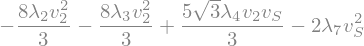

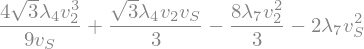

charged physical mass^2 formulas:


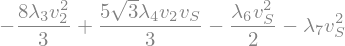

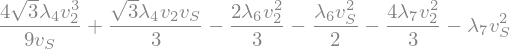

In [ ]:
def zero_pattern(D):
    return [[bool(sp.simplify(D[i, j]) == 0) for j in range(3)] for i in range(3)]

D_A = sp.simplify(R.T * M_A * R)
D_C = sp.simplify(R.T * M_C * R)

print("D_A = R^T M_A R zero pattern:")
for row in zero_pattern(D_A):
    print("  ", row)
print("D_C = R^T M_C R zero pattern:")
for row in zero_pattern(D_C):
    print("  ", row)

print("\nGoldstone eigenvalues (should be exactly 0):", D_A[0, 0], D_C[0, 0])
print("\npseudoscalar physical mass^2 formulas:")
display(D_A[1, 1])
display(D_A[2, 2])
print("charged physical mass^2 formulas:")
display(D_C[1, 1])
display(D_C[2, 2])

$R$ **exactly, fully diagonalizes both sectors** — for any couplings,
not just the benchmark point — with one eigenvalue identically zero (the
Goldstone boson eaten by $Z$ and $W^\pm$ respectively) and two compact
closed-form mass² formulas. This matches [GomezBock21]'s Eq. 30–33: the
pseudoscalar and charged sectors need *no* mixing angle beyond this one
geometric rotation, because it's fixed entirely by the Goldstone theorem
— gauge symmetry alone, nothing dynamical about the potential.

Does the same trick fully diagonalize the CP-even sector `M` from §5?

In plain terms: two of the twelve real scalar degrees of freedom the three doublets started with are *exactly* massless before any dynamics is switched on at all — pure kinematics from the Goldstone theorem, later eaten as the longitudinal modes of $Z$ and $W^\pm$, not a coincidence of these particular $\lambda_k$.

D_S = R^T M R zero pattern:


   [False, True, False]
   [True, False, True]
   [False, True, False]


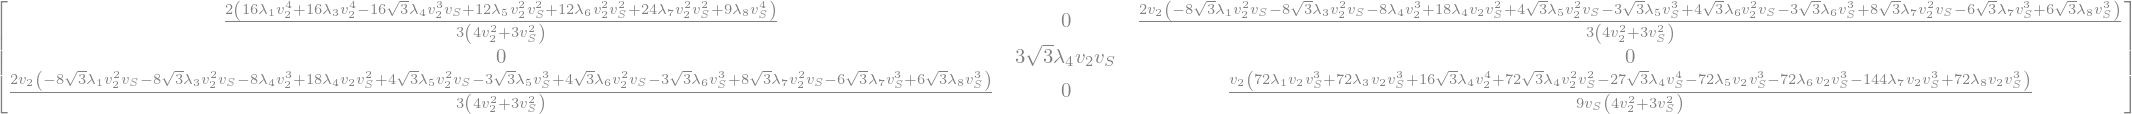

In [ ]:
D_S = sp.simplify(R.T * M * R)
print("D_S = R^T M R zero pattern:")
for row in zero_pattern(D_S):
    print("  ", row)
D_S

Only **one** state decouples this time (row/column 1 — the analogue of
[GomezBock21]'s $h_0$, with the compact closed form
$m_{h_0}^2=3\sqrt3\,\lambda_4v_2v_S$, independent of every other coupling
including $\lambda_8$). The remaining $(0,2)$ block is *not* diagonal — a
genuine, coupling-dependent mixing survives. This is the qualitative
difference [GomezBock21] report: the CP-even sector needs a **second**,
dynamical mixing angle (their $\alpha$, Eq. 36) that the Goldstone-protected
pseudoscalar/charged sectors don't.

## 8. Finishing the CP-even sector: the leftover $2\times2$ block

This is exactly the shape `feynlag.vacuum.diagonalize.solve_mixing_angle_2x2`
/ `diagonalize_orthogonal_2x2` already handles — the same tool
`examples/thdm.py` uses to diagonalize the plain 2HDM's $2\times2$ CP-even
matrix, reused here on the block left over after the geometric rotation
above.

In [ ]:
from feynlag import solve_mixing_angle_2x2, diagonalize_orthogonal_2x2

block = sp.Matrix([[D_S[0, 0], D_S[0, 2]], [D_S[2, 0], D_S[2, 2]]])
theta_expr, tan2theta = solve_mixing_angle_2x2(block)
print("tan(2 theta) is a closed form of length", len(str(tan2theta)),
      "characters (long, but a genuine analytic formula — unlike the raw",
      "cubic-root diagonalization of the full 3x3, this 2x2 reduction stays",
      "closed-form)")

h_a, h_b, H_1, H_2 = sp.symbols("h_a h_b H_1 H_2", real=True)
rot = diagonalize_orthogonal_2x2(block, [h_a, h_b], [H_1, H_2])
rot.angle_relation

tan(2 theta) is a closed form of length 707 characters (long, but a genuine analytic formula — unlike the raw cubic-root diagonalization of the full 3x3, this 2x2 reduction stays closed-form)


707 characters is unreadable as one blob — but it's a sum of terms each
proportional to a single $\lambda_k$. Factoring groups them, which at
least makes the *structure* (which couplings enter, and how) legible even
though the full expression stays long.

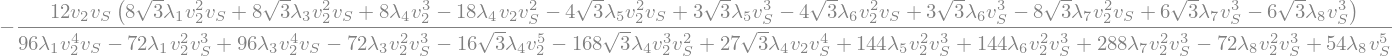

In [ ]:
tan2theta.factor()

## 9. Physical spectrum at a benchmark point

Substituting numeric values (each parameter's own declared
`ExternalParameter.value`, as in previous benchmark checks) into the
*original* λ = 0.05·k demonstration point shows the same lesson as
before, now for all three sectors at once — solving the tadpoles only
guarantees a *stationary* point, and the mass matrices are the
second-derivative stability test.

In [ ]:
lam_syms = [lams[k].s for k in range(1, 9)]
spectrum_exprs = [D_S[1, 1], D_S[0, 0], D_S[0, 2], D_S[2, 2],
                  D_A[1, 1], D_A[2, 2], D_C[1, 1], D_C[2, 2]]
spectrum_fn = sp.lambdify(lam_syms + [v2.s, vS.s], spectrum_exprs, "math")

def block_eigs(a, b, c):
    # real symmetric 2x2: discriminant (a-c)^2 + 4b^2 is never negative
    tr, det = a + c, a * c - b * b
    root = (tr**2 - 4 * det) ** 0.5
    return (tr + root) / 2, (tr - root) / 2

def spectrum(lam_values, v2_val, vS_val):
    h0, a, b, c, A1, A2, Hp1, Hp2 = spectrum_fn(*lam_values, v2_val, vS_val)
    H1m, H2m = block_eigs(a, b, c)
    return dict(h0=h0, H1=H1m, H2=H2m, A1=A1, A2=A2, Hpm1=Hp1, Hpm2=Hp2)

`spectrum(...)` turns any set of couplings into all seven physical
mass² values at once, reusing the closed forms just derived. Now evaluate
it at the same "democratic" $\lambda_k=0.05k$ point used throughout the
notebook so far.

In [ ]:
naive_lams = [0.05 * k for k in range(1, 9)]
naive = spectrum(naive_lams, v2.value, vS.value)
print("naive benchmark mass^2 (GeV^2):", {k: round(v, 2) for k, v in naive.items()})
print("negative directions:", [k for k, v in naive.items() if v < 0])

naive benchmark mass^2 (GeV^2): {'h0': 9560.92, 'H1': 14214.63, 'H2': -2301.34, 'A1': -7985.04, 'A2': -12834.08, 'Hpm1': -3178.38, 'Hpm2': -8027.42}
negative directions: ['H2', 'A1', 'A2', 'Hpm1', 'Hpm2']


In plain terms: a negative mass² here doesn't mean an imaginary-mass
particle — it flags a direction in which the potential curves *downward*
at this point. This benchmark sits on a saddle/hilltop of $V$, not in a
valley, in five of the seven directions.

Five of the seven directions are tachyonic at this naive, "democratic"
benchmark. [GomezBock21] face exactly this problem at scale — their
Section 3.4 scans $\mathcal O(10^{11})$ random points over the eight
self-couplings and keeps only the ones passing unitarity and stability
constraints before ever reporting a mass. We do the same thing here, just
at notebook scale: a small random scan over $\lambda_1,\ldots,\lambda_8$
(same $v_2,v_S$) for the first point where all seven mass² come out
positive.

In [ ]:
import random

rng = random.Random(7)
stable = None
for trial in range(500_000):
    lam_values = [rng.uniform(0.0, 1.5) for _ in range(8)]
    spec = spectrum(lam_values, v2.value, vS.value)
    if all(m2 > 0 for m2 in spec.values()):
        stable = (lam_values, spec)
        break

The scan above just stops at the first point where all seven mass²
come out positive — a stand-in, at notebook scale, for [GomezBock21]'s
$\mathcal O(10^{11})$-point stability/unitarity scan. Read off what it
found.

In [ ]:
lam_values, spec = stable
print("stable point found at trial", trial, "— lambda_k:",
      {k + 1: round(lam_values[k], 3) for k in range(8)})
print("\nmass^2 (GeV^2):", {k: round(v, 2) for k, v in spec.items()})
masses = {k: v ** 0.5 for k, v in spec.items()}
print("\nphysical masses (GeV):", {k: round(v, 2) for k, v in masses.items()})

stable point found at trial 272 — lambda_k: {1: 0.955, 2: 0.063, 3: 0.617, 4: 1.181, 5: 0.46, 6: 1.036, 7: 0.006, 8: 0.457}

mass^2 (GeV^2): {'h0': 56478.91, 'H1': 46526.5, 'H2': 13218.39, 'A1': 7299.66, 'A2': 23283.43, 'Hpm1': 6260.27, 'Hpm2': 10974.67}

physical masses (GeV): {'h0': 237.65, 'H1': 215.7, 'H2': 114.97, 'A1': 85.44, 'A2': 152.59, 'Hpm1': 79.12, 'Hpm2': 104.76}


Seven positive physical masses — three CP-even ($h_0,H_1,H_2$), two
pseudoscalar ($A_1,A_2$), two charged ($H_1^\pm,H_2^\pm$) — plus the two
Goldstone bosons eaten by $Z$ and $W^\pm$, exactly [GomezBock21]'s "nine
physical Higgs bosons, one of which corresponds to the Standard Model
one." As a last cross-check, the CP-even three masses above should agree
with brute-force `M.eigenvals()` at the same point.

In [ ]:
trial_vals = dict(zip(lam_syms, lam_values))
trial_vals[v2.s] = v2.value
trial_vals[vS.s] = vS.value

Mn = sp.N(M.subs(trial_vals))
brute_force = sorted(complex(e).real for e in Mn.eigenvals().keys())
via_rotation = sorted([spec["h0"], spec["H1"], spec["H2"]])
print("brute-force M.eigenvals():   ", [round(x, 4) for x in brute_force])
print("rotation-ansatz h0,H1,H2:    ", [round(x, 4) for x in via_rotation])

brute-force M.eigenvals():    [13218.3871, 46526.5033, 56478.9149]
rotation-ansatz h0,H1,H2:     [13218.3871, 46526.5033, 56478.9149]


## 10. Recap

| Step | Tool | Result |
|---|---|---|
| Declare $S_3$ irreps + gauge groups | `S3`, `SU2`, `U1`, `s3.assign` | $(H_1,H_2)$ in the **2**, $H_S$ in the **1** |
| Build the potential from CG invariants | `S3.doublet_product`, `bra` | 8 $S_3$-covariant quartics, matching the abstract $1\oplus1'\oplus2$ split |
| Check both symmetries at once | `Model.check_invariance` | gauge **and** finite $S_3$ invariance both pass |
| Catch a broken term | `check_discrete_invariance` | a term missing its $H_2$ partner is rejected |
| Solve the tadpoles | `Model.tadpoles`, `sp.solve` | 3 VEVs, 2 free mass parameters → $v_1^2=v_2^2/3$ forced, matching [GomezBock21] |
| CP-even mass matrix | `Model.mass_matrix` | symmetric $3\times3$ matrix on the aligned vacuum |
| Pseudoscalar + charged mass matrices | `Model.mass_matrix(..., charged=True)` | two more $3\times3$ (Hermitian) matrices, no new Lagrangian terms needed |
| Geometric rotation ansatz | hand-built $R(\varphi,\theta)$ | **exactly** diagonalizes pseudoscalar + charged sectors, symbolically, for any couplings |
| Leftover CP-even $2\times2$ block | `solve_mixing_angle_2x2`, `diagonalize_orthogonal_2x2` | analytic $\tan2\alpha$, reusing the same tool `thdm.py` uses for the plain 2HDM |
| Benchmark spectrum | numeric scan over $\lambda_1,\ldots,\lambda_8$ | 7 positive physical masses, matching [GomezBock21]'s "nine physical Higgs bosons" (7 + 2 Goldstones) |

The headline results: a discrete flavor symmetry doesn't just forbid
individual couplings — an over-constrained potential can force the vacuum
itself onto a specific, symmetry-preserving direction, derived here
directly from the symbolic tadpole system rather than assumed. And once
the vacuum is fixed, the Goldstone theorem alone (not any dynamical
coupling) is enough to fully diagonalize two of the three scalar sectors —
only the CP-even sector needs a genuine, coupling-dependent mixing angle,
and only a real (not merely stationary) vacuum, checked by scanning for
positive mass², gives physical particles instead of tachyons.

**Where to go next:**

- `SUN_Groups_Tutorial.ipynb` — a deeper dive into representation theory,
  for continuous gauge groups.
- `docs/manual/declaration.md` — how `S3`'s real-orthogonal generators are
  chosen, and `S3.doublet_product`.
- `docs/manual/ssb.md` — the general tadpole-solving machinery and this
  exact worked case.
- `docs/manual/invariance.md` — the finite vs. infinitesimal invariance
  check, and why the fermion bar-leg transform differs between $S_3$ and
  $Z_N$.
- **[GomezBock21]** M. Gómez-Bock, M. Mondragón, A. Pérez-Martínez,
  *"Scalar and gauge sectors in the 3-Higgs Doublet Model under the
  S₃-symmetry"*, Eur. Phys. J. C **81**, 942 (2021),
  [arXiv:2102.02800](https://arxiv.org/abs/2102.02800),
  [doi:10.1140/epjc/s10052-021-09731-3](https://doi.org/10.1140/epjc/s10052-021-09731-3)
  — the literature model this whole notebook follows.